In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from skimage import data
from skimage.metrics import peak_signal_noise_ratio as psnr, mean_squared_error as mse

from skimage.filters import gaussian, median

from skimage.morphology import footprint_rectangle

In [12]:
def load_image(image_path):
    if os.path.exists(image_path):
        image = Image.open(image_path).convert('L')
        return np.asarray(image, dtype=np.float64)
    return np.asarray(data.camera(), dtype=np.float64)

def add_gaussian_noise(image, std_dev):
    noisy_image = image + np.random.normal(0.0, std_dev, image.shape)
    return np.clip(noisy_image, 0.0, 255.0)

def plot_orginal_and_noisy(original_image, noisy_image):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(original_image, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(noisy_image, cmap='gray')
    plt.title('Sa šumom')
    plt.axis('off')

def denoise_gaussian_filter(image, std_dev):
    return gaussian(image, sigma=std_dev, preserve_range=True)

def denoise_median_filter(image, size):
    return median(image, footprint=footprint_rectangle((size, size)))

def forward_gradient(u):
    gx = np.zeros_like(u)
    gy = np.zeros_like(u)
    gx[:, :-1] = u[:, 1:] - u[:, :-1]
    gy[:-1, :] = u[1:, :] - u[:-1, :]
    return gx, gy

def divergence(px, py):
    div = np.zeros_like(px)
    div[:, 0] = px[:, 0]
    div[:, 1:] = px[:, 1:] - px[:, :-1]
    div[0, :] += py[0, :]
    div[1:, :] += py[1:, :] - py[:-1, :]
    return div

def chambolle_projection(f, lam, dt=0.248, tol=1e-2, max_iter=5000, p=None):
    px = np.zeros_like(f) if p is None else p[0].copy()
    py = np.zeros_like(f) if p is None else p[1].copy()

    for _ in range(max_iter):
        gx, gy = forward_gradient(divergence(px, py) - f / lam)
        norm = np.sqrt(gx * gx + gy * gy)
        denom = 1.0 + dt * norm
        px_new = (px + dt * gx) / denom
        py_new = (py + dt * gy) / denom
        change = max(np.max(np.abs(px_new - px)), np.max(np.abs(py_new - py)))
        px, py = px_new, py_new
        if change <= tol:
            break

    u = np.clip(f - lam * divergence(px, py), 0.0, 255.0)
    return u, (px, py)

def denoise_tv(noisy_image, std_dev=20, n_outer=5, lam=None):
    sigma = std_dev
    n = np.sqrt(noisy_image.size)
    if lam is None:
        lam = 1.0 / (2.1237 / std_dev + 2.0547 / (std_dev ** 2))
    p = None
    u = noisy_image
    for _ in range(n_outer):
        u, p = chambolle_projection(noisy_image, lam, p=p)
        residual = np.linalg.norm(u - noisy_image)
        lam = lam * (n * sigma) / residual
    return u

In [3]:
def compare(*images):

    img_num = len(images) // 2

    plt.figure(figsize=(12, 3*img_num))

    for i in range(img_num):
        plt.subplot(img_num, 2, i + 1)
        plt.imshow(images[2*i], cmap='gray')
        plt.title(images[2*i + 1])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

def plot_signal(*images):

    row = original_image.shape[0] // 2
    img_num = len(images) // 2

    plt.figure(figsize=(12, 3*img_num))

    for i in range(img_num):
        plt.subplot(img_num, 2, 2*i + 1)
        plt.imshow(images[2*i], cmap='gray')
        plt.title(images[2*i + 1])
        plt.axis('off')

        plt.subplot(img_num, 2, 2*i + 2)
        plt.plot(images[2*i][row, :], color='blue', linewidth=1.5)
        plt.title(images[2*i + 1])
        plt.grid(True, alpha=0.3)
        plt.ylim([0, 255])

    plt.tight_layout()
    plt.show()

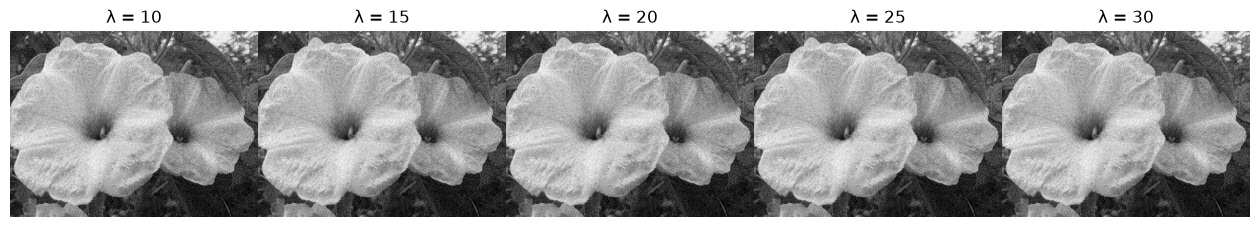

In [10]:
# Kako se Chambolle TV ponaša za različite lambda vrednosti:

original_image = load_image('flowers.jpg')
noisy_image = add_gaussian_noise(original_image, 20)

diff_lambda_values = [10, 15, 20, 25, 30]
tv_denoised_images = []
for value in diff_lambda_values:
    u, _ = chambolle_projection(noisy_image, value)
    tv_denoised_images.append(u)

fig, axes = plt.subplots(
    1, len(tv_denoised_images),
    figsize=(16, 10)
)

for ax, image, value in zip(axes, tv_denoised_images, diff_lambda_values):
    ax.imshow(image, cmap='gray')
    ax.set_title(f'λ = {value}')
    ax.axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

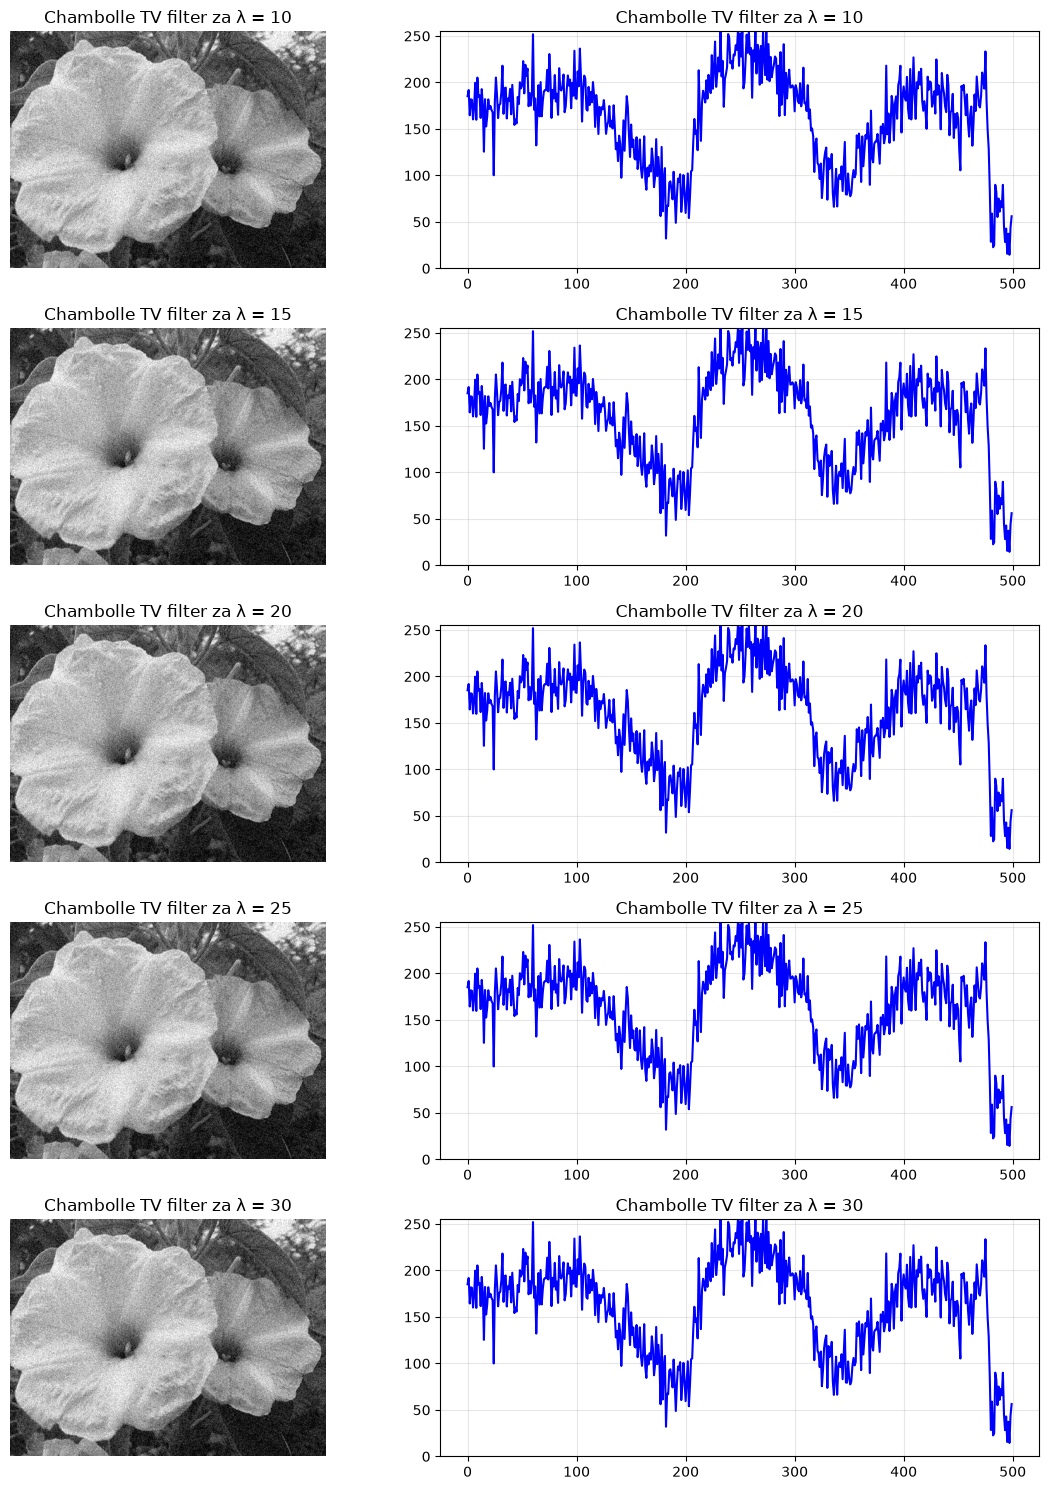

In [5]:
plot_signal(tv_denoised_images[0], 'Chambolle TV filter za λ = 10',\
            tv_denoised_images[1], 'Chambolle TV filter za λ = 15',\
            tv_denoised_images[2], 'Chambolle TV filter za λ = 20',\
            tv_denoised_images[3], 'Chambolle TV filter za λ = 25',\
            tv_denoised_images[4], 'Chambolle TV filter za λ = 30')

In [6]:
# Kako različiti algoritmi reaguju na povećanje intenziteta šuma

std_var = [10, 20, 30, 40, 50]

noisy_images = []
gaussian_denoised_images = []
median_denoised_images = []
tv_denoised_images = []

original_image = load_image('flowers.jpg')

for i, std in enumerate(std_var):

    noisy_images.append(add_gaussian_noise(original_image, std))
    
    gaussian_denoised_images.append(denoise_gaussian_filter(noisy_images[i], 0.5))
    
    median_denoised_images.append(denoise_median_filter(noisy_images[i], 3))

    tv_denoised_images.append(denoise_tv(noisy_images[i], 20))
    
    #plot_orginal_and_noisy(original_image, noisy_images[i])

In [5]:
#plot_signal(gaussian_denoised_images[0],'Chambolle TV filter za std_dev = 10', gaussian_denoised_images[1], 'Chambolle TV filter za std_dev = 20', gaussian_denoised_images[2], \
#            'Chambolle TV filter za std_dev = 30')

In [7]:

psnr_gaussian = [round(psnr(original_image, gaussian_denoised, data_range=255), 2) for gaussian_denoised in gaussian_denoised_images]
psnr_median = [round(psnr(original_image, median_denoised, data_range=255), 2) for median_denoised in median_denoised_images]
psnr_tv = [round(psnr(original_image, tv_denoised, data_range=255), 2) for tv_denoised in tv_denoised_images]

mse_gaussian = [mse(original_image, gaussian_denoised) for gaussian_denoised in gaussian_denoised_images]
mse_median = [mse(original_image, median_denoised) for median_denoised in median_denoised_images]
mse_tv = [mse(original_image, tv_denoised) for tv_denoised in tv_denoised_images]

data = {
    "Intenzitet šuma": std_var,
    "PSNR Gaussian": [str(psnr_gaussian_) + " dB" for psnr_gaussian_ in psnr_gaussian],
    "PSNR Median": [str(psnr_median_) + " dB" for psnr_median_ in psnr_median],
    "PSNR Chambolle TV": [str(psnr_tv_) + " dB" for psnr_tv_ in psnr_tv],
    "MSE Gaussian": mse_gaussian,
    "MSE Median": mse_median,
    "MSE Chambolle TV": mse_tv
}


df = pd.DataFrame(data)
df

,Intenzitet šuma,PSNR Gaussian,PSNR Median,PSNR Chambolle TV,MSE Gaussian,MSE Median,MSE Chambolle TV
0,10,31.78 dB,33.62 dB,26.83 dB,43.154064,28.255205,134.851185
1,20,26.0 dB,29.07 dB,31.78 dB,163.185706,80.558940,43.195813
2,30,22.65 dB,25.94 dB,26.22 dB,353.104082,165.617386,155.353257
3,40,20.37 dB,23.67 dB,21.68 dB,597.108939,279.135554,441.956396
4,50,18.68 dB,21.83 dB,18.83 dB,882.040327,426.866686,850.588853


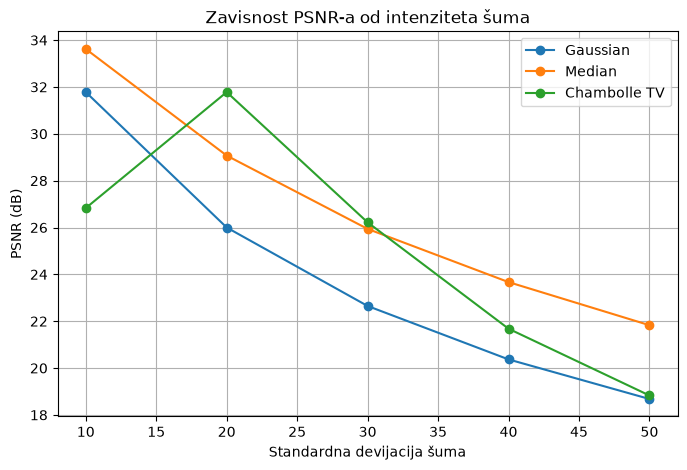

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(std_var, psnr_gaussian, marker='o', label='Gaussian')
plt.plot(std_var, psnr_median, marker='o', label='Median')
plt.plot(std_var, psnr_tv, marker='o', label='Chambolle TV')

plt.xlabel('Standardna devijacija šuma')
plt.ylabel('PSNR (dB)')
plt.title('Zavisnost PSNR-a od intenziteta šuma')

plt.legend()
plt.grid(True)
plt.show()